(257, 257)
0
200
400
600
800


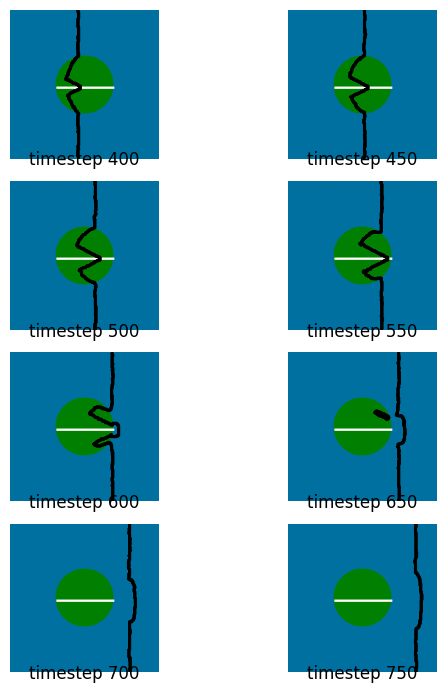

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# Parameters
sorrounding=0.6
plat=0.2
size = 257
radius=50
time=4000
threshold_randomness=0.2
damage_intensity=0.75
countor_levels=50
curvature_constant=0.3
erod_power=1
frac_const=1.4

Ce = np.ones((size,size))*sorrounding

# Insert a resistant circular patch (Ce = 0)
cx, cy, r = 128, 128, radius
y, x = np.ogrid[:size, :size]
mask_resistant = (x - cx)**2 + (y - cy)**2 <= r**2
Ce[mask_resistant] = plat

for z in range(80,180):
    Ce[122][z]=sorrounding*frac_const
    Ce[123][z]=sorrounding*frac_const
    Ce[124][z]=sorrounding*frac_const
    Ce[121][z]=sorrounding*frac_const

erod=Ce.copy()

plt.figure(figsize=(7,7))
plt.style.use("default")


from scipy import ndimage
i=1


Mount= np.ones((size, size))
trans=Mount.T 
trans[0]=np.ones((1,size))*2
mount = trans.T
print(mount.shape)
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
dt=0
survivor=0
count_2s = np.count_nonzero(mount == 2)

while count_2s !=0:
    
        front = np.argwhere(mount == 2)
        for (x, y) in front:
            
            if mount[x][y]==2.0:
                if damage[x][y]>threshold[x][y]:
                    if x<size-1 and y<size-1:
                        if mount[x+1][y]==1: mount[x+1][y]=2
                        if mount[x][y+1]==1: mount[x][y+1]=2
                        if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                    if x>0 and y>0:                            
                        if mount[x-1][y]==1: mount[x-1][y]=2
                        if mount[x][y-1]==1: mount[x][y-1]=2
                        if mount[x-1][y-1]==1: mount[x-1][y-1]=2

                    if x>0 and y>0 and x<size-1 and y<size-1:      
                        if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                        if mount[x-1][y+1]==1: mount[x-1][y+1]=2

                    mount[x][y]=0
                    
                else:
                    eroded_neighbors = 0
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if (dx, dy) != (0, 0):
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < size and 0 <= ny < size:
                                    if mount[nx, ny] == 0: 
                                        eroded_neighbors += 1

                    curvature = (eroded_neighbors - 4) / 4.0  
                    curvature_factor = 1 + curvature_constant * curvature      

                    damage[x][y] += (erod[x][y]**erod_power * damage_intensity * curvature_factor)

        if dt%200==0:
            print(dt)
            
        count_2s = np.count_nonzero(mount == 2)
        plateaus = mount == 2
        structure = np.ones((3,3), dtype=bool)
        labeled, num_features = ndimage.label(plateaus, structure)

        # Create a mask for components that touch the boundary
        boundary_mask = np.zeros_like(labeled, dtype=bool)
        boundary_mask[0, :] = boundary_mask[-1, :] = True
        boundary_mask[:, 0] = boundary_mask[:, -1] = True

        # Find labels of features that touch the boundary
        boundary_labels = np.unique(labeled[boundary_mask])
        # Remove those features
        for label in boundary_labels:
            labeled[labeled == label] = 0

        # Recount remaining features
        sizes = ndimage.sum(plateaus, labeled, range(1, labeled.max() + 1))
        large_stru = np.sum(np.array(sizes) >= 8)

        if large_stru>=1:
            survivor+=1
            
            
        if dt>=400 and dt<800:
            if dt%countor_levels==0:
                plt.subplot(4,2,i)
                plt.contour(mount, colors=['black'], alpha=0.6)
                plt.imshow(erod, cmap="ocean", origin='lower')
                plt.title("timestep " + str(dt), y=-0.1)
                plt.axis("off")
                #print("Significant plateaus:", large_stru, dt, survivor)
                i+=1

        dt+=1
            


#plt.imshow(erod, cmap='viridis', origin='lower')
#plt.colorbar(label='Erodibility (Ce)')
#plt.title('Contours')
plt.tight_layout()
plt.savefig("C:/ECS/simple_case.png")
plt.show()